# 04 — Model Training & Evaluation

Trains one strategy per tier plus baselines, evaluates them on a **held-out
12-week horizon**, and compares per tier.

* **Baselines (all tiers):** naïve, seasonal-naïve, moving-average, and
  *PredictZero* (the trivial all-zero reference).
* **Croston/TSB:** intermittent-demand method (Tiers A+B).
* **Global LightGBM:** Tweedie-objective gradient boosting on the step-3
  feature table, forecast **recursively** over 12 weeks (Tiers A+B).
* **Tier C:** moving-average baseline (too sparse to model).

Metrics: **WAPE**, **MASE** (vs in-sample naïve), MAE, RMSE, and **vol_capture**
(total forecast ÷ total actual). All logic is in `src/train.py` and
`src/evaluate.py`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, features as fe, train as tr, evaluate as ev
KEY, WK, QTY = config.COL_PRODUCT9, config.COL_WEEK, config.COL_SALES_QTY
pd.set_option("display.width", 160); config.ensure_dirs()

## Load inputs and make the time split

In [2]:
weekly = fe.load_weekly_product(); tiers = fe.load_tiers()
feat = pd.read_parquet(config.PROCESSED_DIR / "feature_table.parquet")
clean = fe.load_cleaned(); static = fe.product_static_attributes(clean)

cutoff = ev.train_test_cutoff(weekly); tw = ev.test_weeks(weekly)
print("cutoff:", pd.Timestamp(cutoff).date(),
      "| test:", pd.Timestamp(tw[0]).date(), "..", pd.Timestamp(tw[-1]).date())
train_hist = weekly[weekly[WK] <= cutoff]
actuals = weekly[weekly[WK].isin(tw)][[KEY, WK, QTY]]
ab = tiers.loc[tiers["tier"].isin(["A", "B"]), KEY]

cutoff: 2025-06-23 | test: 2025-06-30 .. 2025-09-15


## Baselines (all tiers)

In [3]:
results = []
fc_naive  = tr.naive_forecast(train_hist, tw)
fc_ma     = tr.moving_average_forecast(train_hist, tw, window=8)
fc_snaive = tr.seasonal_naive_forecast(train_hist, tw)
fc_zero   = tr.predict_zero_forecast(train_hist, tw)
for name, fc in [("Naive", fc_naive), ("SeasonalNaive", fc_snaive),
                 ("MovingAvg8", fc_ma), ("PredictZero", fc_zero)]:
    results.append(ev.evaluate_per_tier(fc, actuals, tiers, train_hist, name))
print("baselines done")

baselines done


## Croston/TSB (intermittent, Tiers A+B)

In [4]:
fc_croston = tr.croston_forecast(train_hist[train_hist[KEY].isin(ab)], tw)
results.append(ev.evaluate_per_tier(fc_croston, actuals, tiers, train_hist, "CrostonTSB"))

## Global LightGBM (Tiers A+B)

Tweedie objective; recursive 12-week forecast. Training is fast (seconds).

In [5]:
feat_train = feat[feat[WK] <= cutoff]
model, feats = tr.train_global_lgbm(feat_train)
ab_hist = train_hist[train_hist[KEY].isin(ab)]
fc_lgbm = tr.recursive_forecast_lgbm(model, feats, ab_hist, static, tiers, tw)
results.append(ev.evaluate_per_tier(fc_lgbm, actuals, tiers, train_hist, "LightGBM"))
print("lightgbm done")

lightgbm done


## Comparison (per tier)

In [6]:
comp = pd.concat(results, ignore_index=True)
comp = comp[~(comp["model"].isin(["CrostonTSB", "LightGBM"]) & (comp["tier"] == "C"))]
comp = comp.sort_values(["tier", "WAPE"]).reset_index(drop=True)
comp.to_csv(config.OUTPUTS_DIR / "model_comparison.csv", index=False)
comp

,tier,model,WAPE,MASE,MAE,RMSE,vol_capture,n_products
0,A,PredictZero,1.0000,0.4245,71.916,450.267,0.000,428
1,A,LightGBM,1.1627,0.5495,83.615,434.213,0.297,428
2,A,Naive,1.3574,0.6071,97.619,488.219,0.470,428
3,A,MovingAvg8,1.5608,0.7236,112.245,439.589,0.901,428
4,A,CrostonTSB,1.6676,0.7655,119.927,417.609,1.068,428
5,A,SeasonalNaive,2.0680,0.8456,148.724,738.127,1.293,428
6,B,PredictZero,1.0000,0.3774,10.444,155.064,0.000,2519
7,B,LightGBM,1.1471,0.6301,11.980,153.415,0.202,2519
8,B,Naive,1.6702,0.6668,17.443,167.447,0.743,2519
9,B,MovingAvg8,1.7540,0.7431,18.319,148.044,1.030,2519


**Reading the table.** `PredictZero` always gets WAPE = 1.0 and 0% volume —
it's the trivial reference. On intermittent demand, point-error metrics
(MAE/WAPE/MASE) reward near-zero forecasts, so among *real* models:

* **LightGBM** has the best per-week point accuracy (lowest MASE) but
  under-forecasts total volume (recursive shrinkage).
* **Moving-average / Croston** capture total volume far better (vol_capture ≈ 1)
  — more useful for restocking.

This trade-off is the key discussion point for the report.

## Feature importance & actual-vs-forecast

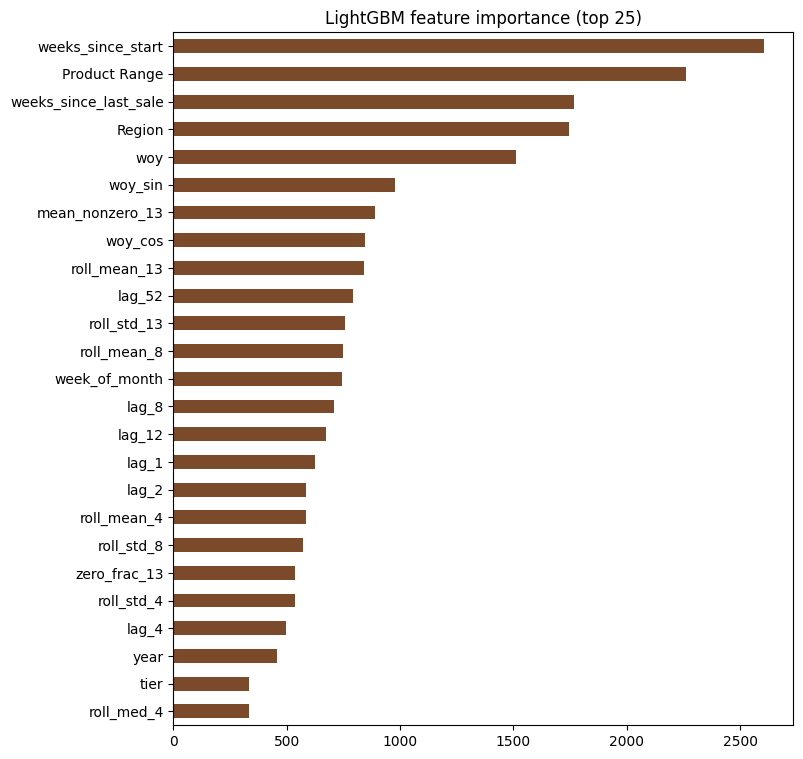

In [7]:
imp = pd.Series(model.feature_importances_, index=feats).sort_values()
fig, ax = plt.subplots(figsize=(8, 9))
imp.tail(25).plot(kind="barh", color="#7a4a2b", ax=ax)
ax.set_title("LightGBM feature importance (top 25)"); plt.show()

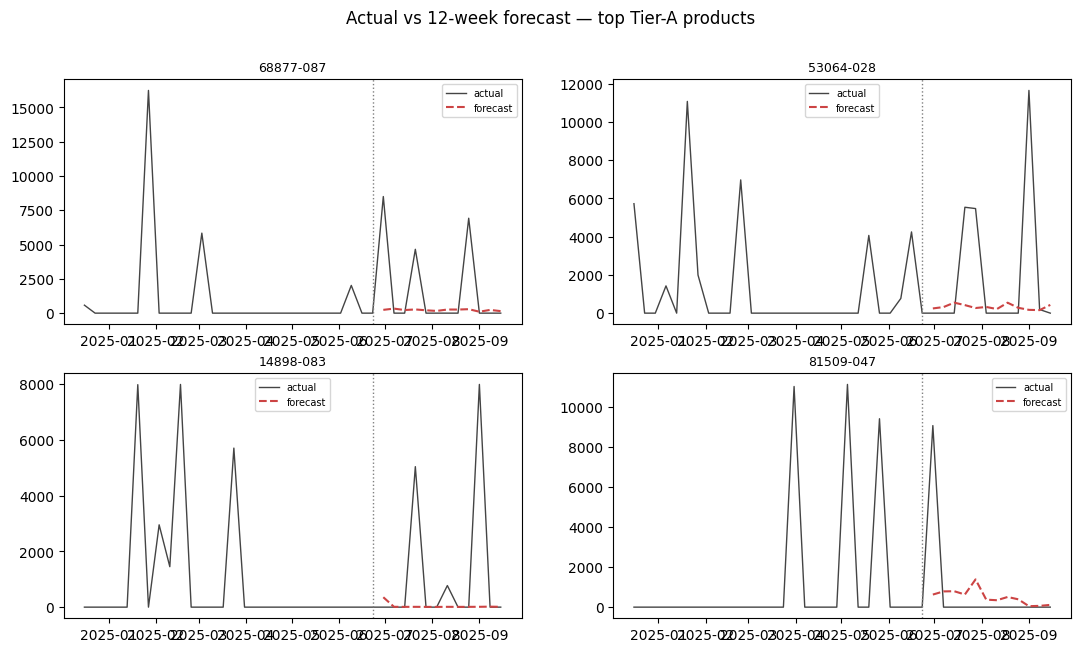

In [8]:
top_a = (tiers[tiers["tier"] == "A"].sort_values("total_qty", ascending=False)
         [KEY].head(4).tolist())
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, pid in zip(axes.ravel(), top_a):
    h = weekly[weekly[KEY] == pid].sort_values(WK).tail(40)
    f = fc_lgbm[fc_lgbm[KEY] == pid]
    ax.plot(h[WK], h[QTY], color="#444", lw=1, label="actual")
    ax.plot(f[WK], f["forecast"], color="#c44", lw=1.5, ls="--", label="forecast")
    ax.axvline(pd.Timestamp(cutoff), color="grey", ls=":", lw=1)
    ax.set_title(pid, fontsize=9); ax.legend(fontsize=7)
fig.suptitle("Actual vs 12-week forecast — top Tier-A products"); plt.show()

## Save the trained model

In [9]:
model.booster_.save_model(str(config.MODELS_DIR / "global_lgbm.txt"))
print("saved:", config.MODELS_DIR / "global_lgbm.txt")

saved: /home/claude/cinnamon_sales_forecasting/outputs/models/global_lgbm.txt


## Hand-off to step 5

Step 5 retrains on **all** history (no holdout) and produces the deliverable
12-week-ahead forecasts: per product and per product×country, written to
`outputs/forecasts/`. Tier C uses the moving-average baseline; A+B use the
global LightGBM (with the volume-bias caveat noted above).